Nama: Alvin Wijaya

NIM: 2802393062


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import os
import cv2

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(print(f"Using device: {device}"))

Using device: cuda
None


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# !unzip -uq "/content/drive/MyDrive/Colab Notebooks/Dataset DL UAS/overhead/storage_tank.zip" -d "/content/drive/MyDrive/Colab Notebooks/Dataset DL UAS/overhead"
# !unzip -uq "/content/drive/MyDrive/Colab Notebooks/Dataset DL UAS/overhead/parking_lot.zip" -d "/content/drive/MyDrive/Colab Notebooks/Dataset DL UAS/overhead"

### A. Loading & Scaling
Kemudian pisahkan dataset menjadi 80% training set, 10% validation set dan 10% test set.

In [ ]:
data_dir_storage = Path('/content/drive/MyDrive/Colab Notebooks/Dataset DL UAS/overhead/storage_tank')
data_dir_parking = Path('/content/drive/MyDrive/Colab Notebooks/Dataset DL UAS/overhead/parking_lot')
IMG_SIZE = 28

#load & scale data
def load_data(data_dir, class_label):
  images = []
  labels = []

  for img_path in data_dir.glob("*.jpg"):
      # Load gambar menggunakan OpenCV
      img = cv2.imread(str(img_path))

      if img is not None:
          # Ubah warna ke grayscale
          img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

          # Resize semua gambar agar konsisten
          img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

          images.append(img)
          labels.append(class_label)

  X = np.array(images, dtype=np.float32)
  y = np.array(labels)

  # Scaling & Normalisasi: Mengubah nilai piksel dari [0, 255] menjadi [0, 1]
  # Memaksa setiap gambar memiliki rentang kontras [0, 1] yang sempurna secara independen
  for i in range(len(X)):
      min_val = np.min(X[i])
      max_val = np.max(X[i])
      if max_val - min_val > 0:
          X[i] = (X[i] - min_val) / (max_val - min_val)
      else:
          X[i] = X[i] * 0.0

  print(f"Total data berhasil di-load: {X.shape[0]} gambar")
  print(f"Shape dataset setelah scaling: {X.shape}")
  return X, y

In [6]:
X1, y1 = load_data(data_dir_storage, 0)
X2, y2 = load_data(data_dir_parking, 1)

Total data berhasil di-load: 1000 gambar
Shape dataset setelah scaling: (1000, 28, 28)
Total data berhasil di-load: 1000 gambar
Shape dataset setelah scaling: (1000, 28, 28)


In [7]:
X = np.concatenate((X1, X2), axis=0)
y = np.concatenate((y1, y2), axis=0)
print(f"\nTotal Gabungan Dataset: X shape = {X.shape}, y shape = {y.shape}")


Total Gabungan Dataset: X shape = (2000, 28, 28), y shape = (2000,)


#### A.1 View data

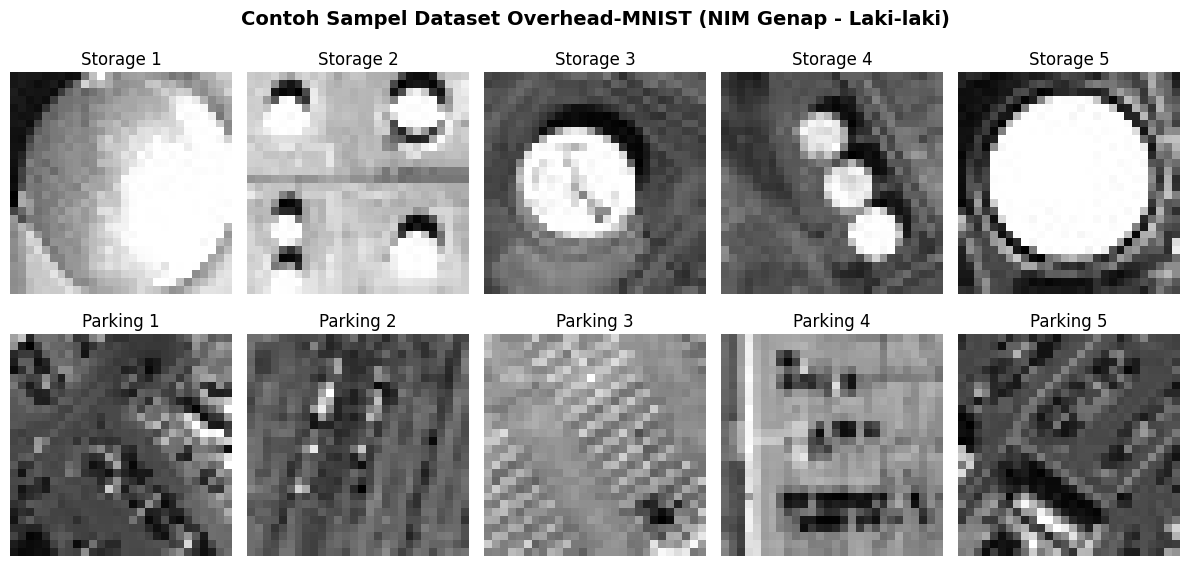

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(5):
    # Baris 0: Storage Tanks (X1)
    axes[0, i].imshow(X1[i], cmap ='gray')
    axes[0, i].set_title(f"Storage {i+1}")
    axes[0, i].axis('off')

    # Baris 1: Parking Lot (X2)
    axes[1, i].imshow(X2[i], cmap = 'gray')
    axes[1, i].set_title(f"Parking {i+1}")
    axes[1, i].axis('off')

plt.suptitle("Contoh Sampel Dataset Overhead-MNIST (NIM Genap - Laki-laki)", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

Datase MNIST ini berisi image satelit berdimensi kecil yang menangkap gambar storage_tanks dan parking lot. Adapun perbedaan dari kedua kelas gambar ini adalah storage tanks memiliki definisi image yang lebih simpel untuk dipelajari karena minimnya keanekaragaman objek utama. Sedangkan parking lot bisa menjadi tantangan karena besarnya cardinalitas dari tempat parkir.

#### A.2 Data Splitting

In [9]:
# Tahap 1: Pisahkan 80% Train dan 20% Temp (Val + Test)
# Menggunakan stratify=y agar proporsi storage_tank dan parking_lot seimbang di setiap split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [10]:
# Tahap 2: Bagi 20% Temp menjadi 10% Val dan 10% Test (50:50)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [11]:
print("\n=== Hasil Akhir Pembagian Dataset ===")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape  : {X_val.shape}  | y_val shape  : {y_val.shape}")
print(f"X_test shape : {X_test.shape}  | y_test shape : {y_test.shape}")


=== Hasil Akhir Pembagian Dataset ===
X_train shape: (1600, 28, 28) | y_train shape: (1600,)
X_val shape  : (200, 28, 28)  | y_val shape  : (200,)
X_test shape : (200, 28, 28)  | y_test shape : (200,)


### B. Model Baseline

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.image import ssim as tf_ssim
from tensorflow.keras.regularizers import l2
import numpy as np

#### B.1 Create Baseline Model

Baseline model yang digunakan adalah sebuah **Autoencoder** yang terdiri dari dua komponen utama: **Encoder** (untuk mereduksi dimensi gambar menjadi representasi laten) dan **Decoder** (untuk merekonstruksi kembali gambar dari representasi laten tersebut).

Model akan menerima input gambar grayscale 28 x 28 x 1 px

Input encoder akan menerima gambar satelit grayscale

In [ ]:
IMG_SHAPE = (28, 28, 1)

encoder_input = layers.Input(shape=IMG_SHAPE, name="Input_Encoder")

#padding='same' agar dimensi spasial tetap 28x28
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="Conv_ReLU_Enc")(encoder_input)

x = layers.MaxPooling2D((2, 2), padding='same', name="Max_Pool")(x)

# Flatten dimensi
x = layers.Flatten(name="Flatten")(x)

# Fully Connected + ReLU (Latent Space: 128)
latent_space = layers.Dense(128, activation='relu', name="Latent_128")(x)
encoder = models.Model(encoder_input, latent_space, name="Encoder_Model")

In [14]:
# --- DECODER ---
decoder_input = layers.Input(shape=(128,), name="Input_Decoder")

# Fully Connected (6272) -> Tanpa ReLU eksplisit di gambar arsitektur
x = layers.Dense(6272, name="Fully_Connected_Dec")(decoder_input)

# Reshape (14x14x32)
x = layers.Reshape((14, 14, 32), name="Reshape")(x)

# Upsampling (28x28x32)
x = layers.UpSampling2D((2, 2), name="Upsampling")(x)

# Conv + ReLU (28x28x32)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="Conv_ReLU_Dec")(x)

# Conv + Sigmoid (28x28x1) -> Output rekonstruksi final
decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="Conv_Sigmoid_Dec")(x)
decoder = models.Model(decoder_input, decoder_output, name="Decoder_Model")

In [ ]:
#Gabung keduanya menjadi autoencoder
autoencoder_input = layers.Input(shape=IMG_SHAPE)
encoded_img = encoder(autoencoder_input)
decoded_img = decoder(encoded_img)

autoencoder = models.Model(autoencoder_input, decoded_img, name="Autoencoder")

Karena pixel bernilai [0, 1] setelah scaling, gunakan MSE
Kelebihan MSE: 
- sangat sensitif terhadap outlier dan menghukum model jika prediksi jauh dari data real
- memiliki soft gradient descent yang stabil dan efisien. 
- Mempermudah model untuk konvergen.Gradien Otomatis Mengecil Saat Mendekati Target

Kelemahan MSE:
- gambar menjadi blurry karena ingin meminimalkan rata2 kesalahan pixel secara keseluruhan.
- rentan terhadap noise, terkadang membuat model mengabaikan pola utama
- tidak menilai seperti manusia, ia menilai berdasarkan statistik pixel bukan ketajaman definisi struktur dan spasial.


In [ ]:
# Compile Model
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Model (Functional)      │ (None, 128)            │       803,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Model (Functional)      │ (None, 28, 28, 1)      │       818,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,889 (6.19 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

#### B.2 Training Loop

In [17]:
print("\nMemulai training Autoencoder...")
history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, X_val)
)


Memulai training Autoencoder...
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0575 - val_loss: 0.0406
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0345 - val_loss: 0.0321
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0290 - val_loss: 0.0282
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0259 - val_loss: 0.0257
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0237 - val_loss: 0.0246
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0221 - val_loss: 0.0230
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0209 - val_loss: 0.0219
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0198 - val_loss: 0.0209
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0189 - val_loss: 0.0201
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0182 - val_loss: 0.0201
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0175 - val_loss: 0.0194
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0

#### B.3 Evaluate Baseline Model

In [18]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

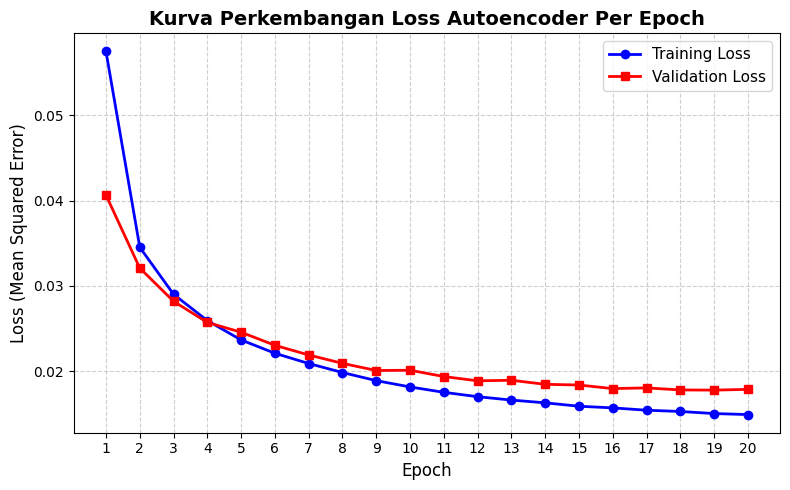

In [19]:
plt.figure(figsize=(8, 5))

# Plot Garis untuk Train Loss dan Validation Loss
plt.plot(epochs, train_loss, 'b-o', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, 'r-s', label='Validation Loss', linewidth=2)

# Mengatur Judul dan Label Grafik
plt.title('Kurva Perkembangan Loss Autoencoder Per Epoch', fontsize=14, weight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Memastikan angka epoch di sumbu X berupa bilangan bulat
plt.xticks(epochs)

plt.tight_layout()
plt.show()

Kurva grafik menunjukan:
1. Training Loss dan Validation Loss mengalami penurunan konsisten sejak epoch pertama hingga epoch ke 20 dengan selisih bound yang sangat tipis.

2. Kecilnya gap dan stabil (0.0149 vs 0.0179) menunjukan model memiliki kemampuan generalisasi yang baik pada data baru yang belum pernah dilihat sebelumnya.

3. Tidak Ada Gejala Divergensi (Rebound): Model dikatakan overfitting apabila kurva Validation Loss berbalik naik ke atas (membentuk pola huruf U) di saat Training Loss terus turun ke bawah. Sedangkan kurva validasi memiliki gejala plataeu tanpa tanda kenaikan kembali.

In [ ]:
X_test_recon = autoencoder.predict(X_test)

ssim_scores = []

# Hitung nilai SSIM untuk setiap pasangan gambar asli vs rekonstruksi pada data test
for i in range(len(X_test)):
    # buang channel extra menjadi (28, 28) untuk kompatibilitas
    img_true = np.squeeze(X_test[i])
    img_pred = np.squeeze(X_test_recon[i])

    # Hitung SSIM dengan menentukan data_range=1.0 karena pixel sudah di-scale [0, 1]
    score = ssim(img_true, img_pred, data_range=1.0)
    ssim_scores.append(score)

mean_ssim = np.mean(ssim_scores)
print(f"\n=== Hasil Evaluasi ===")
print(f"Rata-rata Structural Similarity Index (SSIM) pada Data Test: {mean_ssim:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step

=== Hasil Evaluasi ===
Rata-rata Structural Similarity Index (SSIM) pada Data Test: 0.4933


SSIM atau Structural similarity index measure score adalah metrik persepsi untuk mengevaluasi kualitas kompresi gambar yang menilai degradasi kualitas visual dibanding original image. Skala:

1.0: Identical images.

0.99+: Excellent, dengan artifak minor

0.95–0.99: Very Good, similaritas sangat tinggi dengan beberpaa noise/artifak

0.90–0.95: Good, perbedaan dapat dirasakan namun masih bagus

0.80–0.90: Acceptable, ada cukup degradasi

Below 0.80: Moderate hingga sangat buruk.

Model baseline berhasil melakukan generalisasi dengan sangat baik dan bebas dari overfitting. Namun, evaluasi SSIM dengan skor 0.4933 menunjukkan bahwa meski rekonstruksi nilai piksel secara global sudah baik (MSE rendah), detail struktur mikro dan ketajaman objek pada citra hasil rekonstruksi masih memiliki room for improvement

### C. Modifikasi Baseline + Hyperparameter Tuning

#### C.1 Modify Baseline

In [ ]:
#Encoder
input_encoder = layers.Input(shape=(28, 28, 1), name="Input_Encoder")

x = layers.Conv2D(16, (3, 3), padding='same')(input_encoder)
x = layers.BatchNormalization()(x)
x = layers.Activation('leaky_relu')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)       

x = layers.Conv2D(32, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('leaky_relu')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)       

flatten_shape = x.shape[1:]                              
x = layers.Flatten()(x)                                 

latent_space = layers.Dense(128, activation='leaky_relu', name="Latent_256")(x)
x = layers.Dropout(0.2)(x)

encoder = models.Model(input_encoder, latent_space, name="Fixed_Encoder")

#Decoder
decoder_input = layers.Input(shape=(128,), name="Input_Decoder")
x = layers.Dense(int(np.prod(flatten_shape)), activation='leaky_relu')(decoder_input) 
x = layers.Reshape(flatten_shape)(x)                          

x = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(x)  
x = layers.BatchNormalization()(x)
x = layers.Activation('leaky_relu')(x)

x = layers.Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same')(x)  
x = layers.BatchNormalization()(x)
x = layers.Activation('leaky_relu')(x)

x = layers.Conv2D(16, (3, 3), padding='same')(x)
x = layers.Activation('leaky_relu')(x)

output_decoder = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
decoder = models.Model(decoder_input, output_decoder, name="Fixed_Decoder")

Modifikasi Baseline:

#### 1. Sisi Encoder
- **Baseline:** Input -> Conv2D -> MaxPooling2D -> Flatten (6272) -> Latent Space (128)
- **Modified:** Input -> Conv2D -> `[BatchNorm -> LeakyReLU -> MaxPooling2D] × 2` -> Flatten (3136) -> Latent Space (128)

Dampak: Dimensi sebelum *Flatten* menyusut lebih optimal menjadi 7 * 7 * 64, memadatkan informasi spasial sebelum masuk ke *Bottleneck*.

#### 2. Sisi Decoder
- **Baseline:** Input Latent -> Dense -> Reshape (14, 14, 32) -> UpSampling2D -> Conv2D -> Output
- **Modified:** Input Latent-> Dense -> `[Reshape (7, 7, 64) -> Conv2DTranspose -> BatchNorm -> LeakyReLU] × 2` -> Conv2D -> Output (Sigmoid)

Dampak: Konstruksi bentuk gambar dilakukan secara bertahap menggunakan *Convolution Transpose* berselang (*strided*), menghasilkan transisi piksel rekonstruksi yang lebih halus dan presisi.

Melihat kelemahan MSE yaitu membuat gambar menjadi blurry akibat terlalu fokus mengkoreksi rata rata error di seluruh pixel gambar, kita perlu memberikan bobot koreksi yang disesuaikan agar MSE tidak membuat gambar hasil autoencoder terlalu blurry. Kita dapat kombinasikan mse (20%) dengan ssim (80%) dalam kombinasi metric perbaikan optimizer

Ini dapat membuat model lebih fokus mempertajam gambar dengan kompensasi loss yang berpotensi lebih besar dari baseline.

In [ ]:
def mse_ssim_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    ssim_val = tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0, filter_size=3))
    ssim_loss = 1.0 - ssim_val

    # 3. Bobot Hybrid (0.2 MSE + 0.8 SSIM)
    return (0.2 * mse) + (0.8 * ssim_loss)

In [ ]:
def ssim_metric(y_true, y_pred):
    # Memastikan y_true memiliki dimensi channel yang kompatibel
    if len(y_true.shape) == 3:
        y_true = tf.expand_dims(y_true, axis=-1)
    if len(y_pred.shape) == 3:
        y_pred = tf.expand_dims(y_pred, axis=-1)

    # Hitung SSIM dengan aman
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0, filter_size=3))

In [ ]:
# Gabungkan modified encoder decoder menjadi autoencoder
autoencoder_input = layers.Input(shape=(28, 28, 1))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)
autoencoder = models.Model(autoencoder_input, decoded, name="Final_Autoencoder")

autoencoder.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate = 0.001),
    loss=mse_ssim_loss, #Fungsi custom hybrid mse & ssim sblmnya
    metrics=[ssim_metric]
)

#### C.2 Model Summary

In [25]:
autoencoder.summary()

Model: "Final_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fixed_Encoder (Functional)      │ (None, 128)            │       205,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fixed_Decoder (Functional)      │ (None, 28, 28, 1)      │       244,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 450,209 (1.72 MB)

 Trainable params: 449,921 (1.72 MB)

 Non-trainable params: 288 (1.12 KB)

#### C.3 Hyperparameter Tuning Loop

In [ ]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='ssim_metric',   # Memantau kerugian data validasi
        mode = 'max',           # make sure makin naik
        factor=0.2,           # Kurangi lr 20% jika macet
        patience=3,           # Durasi watch and see 3 epoch
        min_lr=1e-6,          # Minimum learning rate
        verbose=1             
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_autoencoder.keras', monitor='ssim_metric', mode = 'max', save_best_only=True
    )
]

In [27]:
history_tuning = autoencoder.fit(
    X_train, X_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, X_val),
    callbacks=callbacks
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 382ms/step - loss: 0.4873 - ssim_metric: 0.1557 - val_loss: 0.7523 - val_ssim_metric: 0.1979 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.3573 - ssim_metric: 0.2079 - val_loss: 0.7435 - val_ssim_metric: 0.1953 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3129 - ssim_metric: 0.2501 - val_loss: 0.7301 - val_ssim_metric: 0.1909 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2800 - ssim_metric: 0.2836 - val_loss: 0.7222 - val_ssim_metric: 0.1874 - learning_rate: 0.0010
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2522 - ssim_metric: 0.3087 - val_loss: 0.6873 - val_ssim_metric: 0.1919 - learning_rate: 0.0010
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2412 - ssim_metric: 0.3290 - val_loss: 0.6572 - val_ssim_metric: 0.2002 - learning_rate: 0.0010
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/ste

#### C.4 Evaluating Modified Model

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step


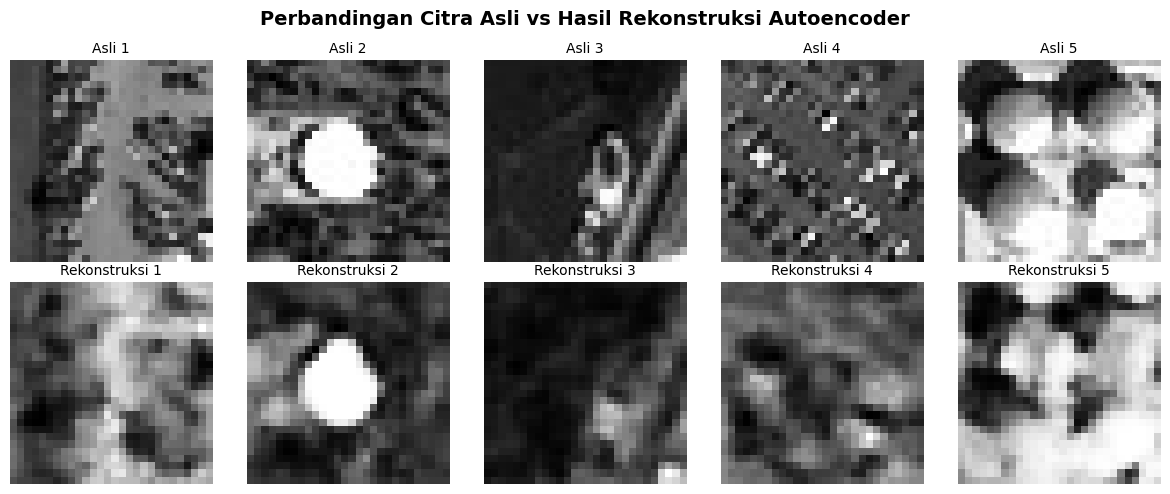

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# 1. PREDIKSI DATA TEST
X_test_recon = autoencoder.predict(X_test)

# 2. FUNGSI VISUALISASI PERBANDINGAN
def plot_reconstruction_comparison(X_true, X_pred, n_images=5):
    plt.figure(figsize=(12, 5))

    for i in range(n_images):
        # --- BARIS 1: GAMBAR ASLI ---
        ax = plt.subplot(2, n_images, i + 1)
        # Menggunakan np.squeeze untuk membuang dimensi channel tunggal (28,28,1) -> (28,28)
        plt.imshow(np.squeeze(X_true[i]), cmap='gray')
        plt.title(f"Asli {i+1}", fontsize=10)
        plt.axis('off')

        # --- BARIS 2: GAMBAR REKONSTRUKSI ---
        ax = plt.subplot(2, n_images, i + 1 + n_images)
        plt.imshow(np.squeeze(X_pred[i]), cmap='gray')
        plt.title(f"Rekonstruksi {i+1}", fontsize=10)
        plt.axis('off')

    plt.suptitle("Perbandingan Citra Asli vs Hasil Rekonstruksi Autoencoder", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

plot_reconstruction_comparison(X_test, X_test_recon, n_images=5)

Evaluasi perbandingan gambar real vs gambar hasil autoencoder menunjukan:
1. Secara keseluruhan model autoencoder modified mengalami peningkatan kemampuan rekonstruktuksi dalam mempertahankan informasi spasial dan struktural objek.

- Gambar 1: Model mengenali orientasi dan pola barisan kendaraan di tempat parkir meski ada kehalusan pada objek terkecil.

- Gambar 2: model berhasil mengidentifikasi storage tanks berserta orientasinya dan memisahkan objek storage tank dengan latar belakang dengan cukup akurat

- Gambar 3: Struktur garis diagonal berhasil direplikasi ulang oleh autoencoder meski detil spasialnya mengalami smoothing

- Gambar 4: Area tempat parkir yang memiliki kompleksitas spasial yang tinggi memberi tantangan yang besar bagi autoencoder. Meski berhasil direkonstruksi secara umum, masih ada detil kecil yang mengalami smoothing. Secara umum Bottleneck dari latent space 128 berhasil memadatkan informasi esensial citra.

- Gambar 5: Pola melingkar dari kumpulan tangki mampu direkonstruksi secara spasial dengan gradasi pencahayaan yang mirip citra asli meski edges mengalami sedikit smoothing.

Balancenya keburaman dan pemisahan objek yang baik oleh model autoencoder menunjukan pendekatan hybrid mse dan ssim berbobot memaksa model untuk fokus pada aspek persepsi manusia, dan mempertahankan kontrak lokal, bentuk geometris, dan pencahayaan objek. Pemisahan antar objek dan latar belakang menjadi lebih tegas.

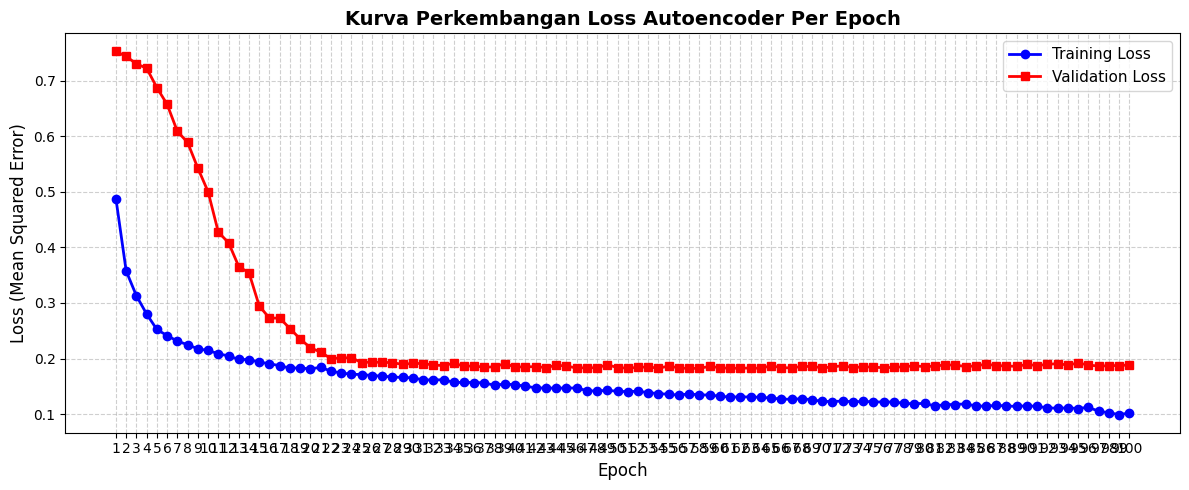

In [29]:
train_loss = history_tuning.history['loss']
val_loss = history_tuning.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 5))

# Plot Garis untuk Train Loss dan Validation Loss
plt.plot(epochs, train_loss, 'b-o', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, 'r-s', label='Validation Loss', linewidth=2)

# Mengatur Judul dan Label Grafik
plt.title('Kurva Perkembangan Loss Autoencoder Per Epoch', fontsize=14, weight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Memastikan angka epoch di sumbu X berupa bilangan bulat
plt.xticks(epochs)

plt.tight_layout()
plt.show()

Kurva Perkembangan model ini menunjukan:
- Menggunakan Hybrid (MSE 20% + SSIM 80%) memberikan efek buram yang minimum namun harus dikompensasi dengan MSE loss yang lebih besar dibanding model Baseline yang konsisten dibawah ~0.01 dibanding ~0.2 - 0.1 oleh modified autoencoder.

- Meski begitu model tetap berhasil konvergen di epoch ke ~20 dan mengalami plataeu yang mengindikasikan tidak terjadinya overfitting. Dapat dilihat bound yang sehat antar training dan validasi sejak konvergensi di epoch 20.

- Beberapa awal epoch model cenderung lebih pintar di training data dan gap 0.2 dengan validation merupakan hal yang umum. Setelah epoch 20-an, model berhasil melakukan generalisasi.

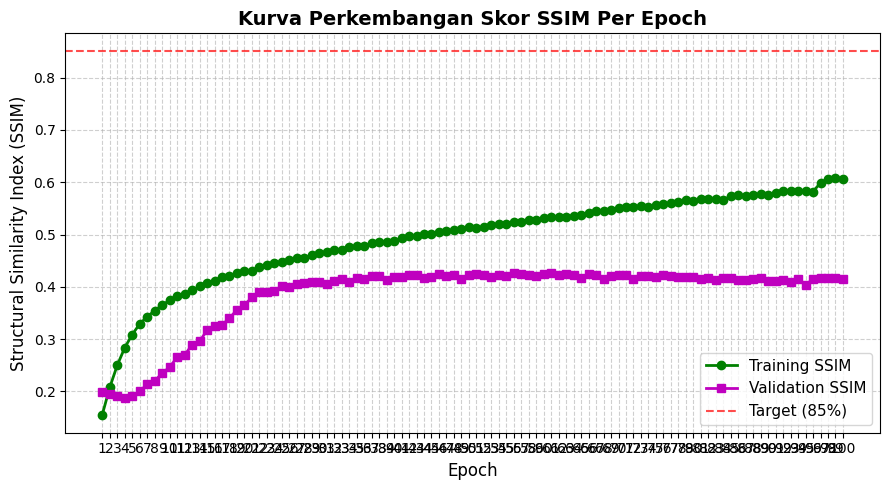

In [30]:
import matplotlib.pyplot as plt

# Mengambil data SSIM dari history training
train_ssim = history_tuning.history['ssim_metric']
val_ssim = history_tuning.history['val_ssim_metric']
epochs = range(1, len(train_ssim) + 1)

plt.figure(figsize=(9, 5))

# Plot Garis untuk Train SSIM dan Validation SSIM
plt.plot(epochs, train_ssim, 'g-o', label='Training SSIM', linewidth=2)
plt.plot(epochs, val_ssim, 'm-s', label='Validation SSIM', linewidth=2)

# Garis bantu target 85% Anda
plt.axhline(y=0.85, color='r', linestyle='--', alpha=0.7, label='Target (85%)')

# Mengatur Judul dan Label Grafik
plt.title('Kurva Perkembangan Skor SSIM Per Epoch', fontsize=14, weight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Structural Similarity Index (SSIM)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')
plt.xticks(epochs)

plt.tight_layout()
plt.show()

In [31]:
X_test_recon = autoencoder.predict(X_test)

ssim_scores = []

# Hitung nilai SSIM untuk setiap pasangan gambar asli vs rekonstruksi pada data test
for i in range(len(X_test)):
    # Squeeze digunakan untuk membuang dimensi channel tunggal (28, 28, 1) menjadi (28, 28) demi library skimage
    img_true = np.squeeze(X_test[i])
    img_pred = np.squeeze(X_test_recon[i])

    # Hitung SSIM dengan menentukan data_range=1.0 karena pixel sudah di-scale [0, 1]
    score = ssim(img_true, img_pred, data_range=1.0)
    ssim_scores.append(score)

mean_ssim = np.mean(ssim_scores)
print(f"\n=== Hasil Evaluasi ===")
print(f"Rata-rata Structural Similarity Index (SSIM) pada Data Test: {mean_ssim:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

=== Hasil Evaluasi ===
Rata-rata Structural Similarity Index (SSIM) pada Data Test: 0.6007


Implementasi Pendekatan Hybrid dan Mengubah beberapa arsitektur dari autoencoder berhasil menaikan skor final SSIM dari 0.49 menjadi 0.6 dan konsisten di test set juga. Peningkatan performa sekitar 22.4% menandakan modifikasi model baseline efektif membantu model menangkap informasi struktural gambar dengan lebih baik.

Meski begitu, ada indikasi overfitting pada kurva perkembangan metrik SSIM dimana model autoencoder memiliki performa yang lebih baik di training set dan tidak setara kemampuannya pada validation set. Skor SSIM pada validation set stagnan (plateu) pada ~0.4 setelah epoch ~20. 

Ini menandakan masih ada ruang improvement agar model bisa melakukan generalisasi lebih lagi. Performa autoencoder yang kurang ideal disebabkan oleh beberapa hal:

Keterbatasan jumlah data (1000 gambar / kelas (2 kelas)) sebelum splitting menjadi tantangan autoencoder untuk memproduksi output ideal. Autoencoder secara umum membutuhkan lebih banyak dataset gambar untuk dimensi kecil.